In [78]:
import pandas as pd , os , matplotlib.pyplot as plt , seaborn as sns

In [79]:

def load_data(file_path: str) -> pd.DataFrame:
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"[!] error to find: {file_path}")
    df = pd.read_csv(file_path)
    df['Gmt time'] = pd.to_datetime(df['Gmt time'])
    df = df.set_index('Gmt time')
    df = df.sort_index()
    return df

def generate_ingestion_summary(df: pd.DataFrame) -> None:
    print("---:: Data Ingestion ::---")
    print(f"[-] Total Data Points (1m Candel Count): {len(df)}")
    print(f"[-] Start Date: {df.index.min()}")
    print(f"[-] End Date: {df.index.max()}")
    print("\n[-] Data Columns & Types:")
    print(df.dtypes)
    print("\n[-] First 10 Rows:")
    print(df.head(10))


In [80]:
file_path = "/home/karim/PycharmProjects/Algorithmic-Price-Smoothing-With-Advanced-Kalman-Filtering/data/XAUUSD_1m.csv"
load_df = load_data(file_path)
generate_ingestion_summary(load_df)

---:: Data Ingestion ::---
[-] Total Data Points (1m Candel Count): 4366107
[-] Start Date: 2015-01-01 00:01:00
[-] End Date: 2025-06-30 22:59:00

[-] Data Columns & Types:
Unnamed: 0      int64
Open          float64
High          float64
Low           float64
Close         float64
Volume        float64
dtype: object

[-] First 10 Rows:
                     Unnamed: 0      Open      High       Low     Close  \
Gmt time                                                                  
2015-01-01 00:01:00           1  1183.701  1183.701  1183.701  1183.701   
2015-01-01 00:02:00           2  1183.701  1183.701  1183.701  1183.701   
2015-01-01 00:03:00           3  1183.701  1183.701  1183.701  1183.701   
2015-01-01 00:04:00           4  1183.701  1183.701  1183.701  1183.701   
2015-01-01 00:05:00           5  1183.701  1183.701  1183.701  1183.701   
2015-01-01 00:06:00           6  1183.701  1183.701  1183.701  1183.701   
2015-01-01 00:07:00           7  1183.701  1183.701  1183.701

In [81]:
load_df.describe()

,Unnamed: 0,Open,High,Low,Close,Volume
count,4.366107e+06,4.366107e+06,4.366107e+06,4.366107e+06,4.366107e+06,4.366107e+06
mean,2.274061e+05,1.638723e+03,1.638884e+03,1.638561e+03,1.638722e+03,1.056005e+04
std,1.429783e+05,3.916623e+02,3.917188e+02,3.916057e+02,3.916631e+02,2.559628e+04
min,0.000000e+00,1.046481e+03,1.046850e+03,1.046231e+03,1.046420e+03,0.000000e+00
25%,1.044770e+05,1.283118e+03,1.283238e+03,1.282999e+03,1.283118e+03,0.000000e+00
50%,2.172680e+05,1.696618e+03,1.696955e+03,1.696328e+03,1.696618e+03,2.260000e-02
75%,3.385480e+05,1.882258e+03,1.882553e+03,1.881948e+03,1.882258e+03,4.250000e+03
max,5.255990e+05,3.434755e+03,3.435755e+03,3.434235e+03,3.434775e+03,2.534420e+06


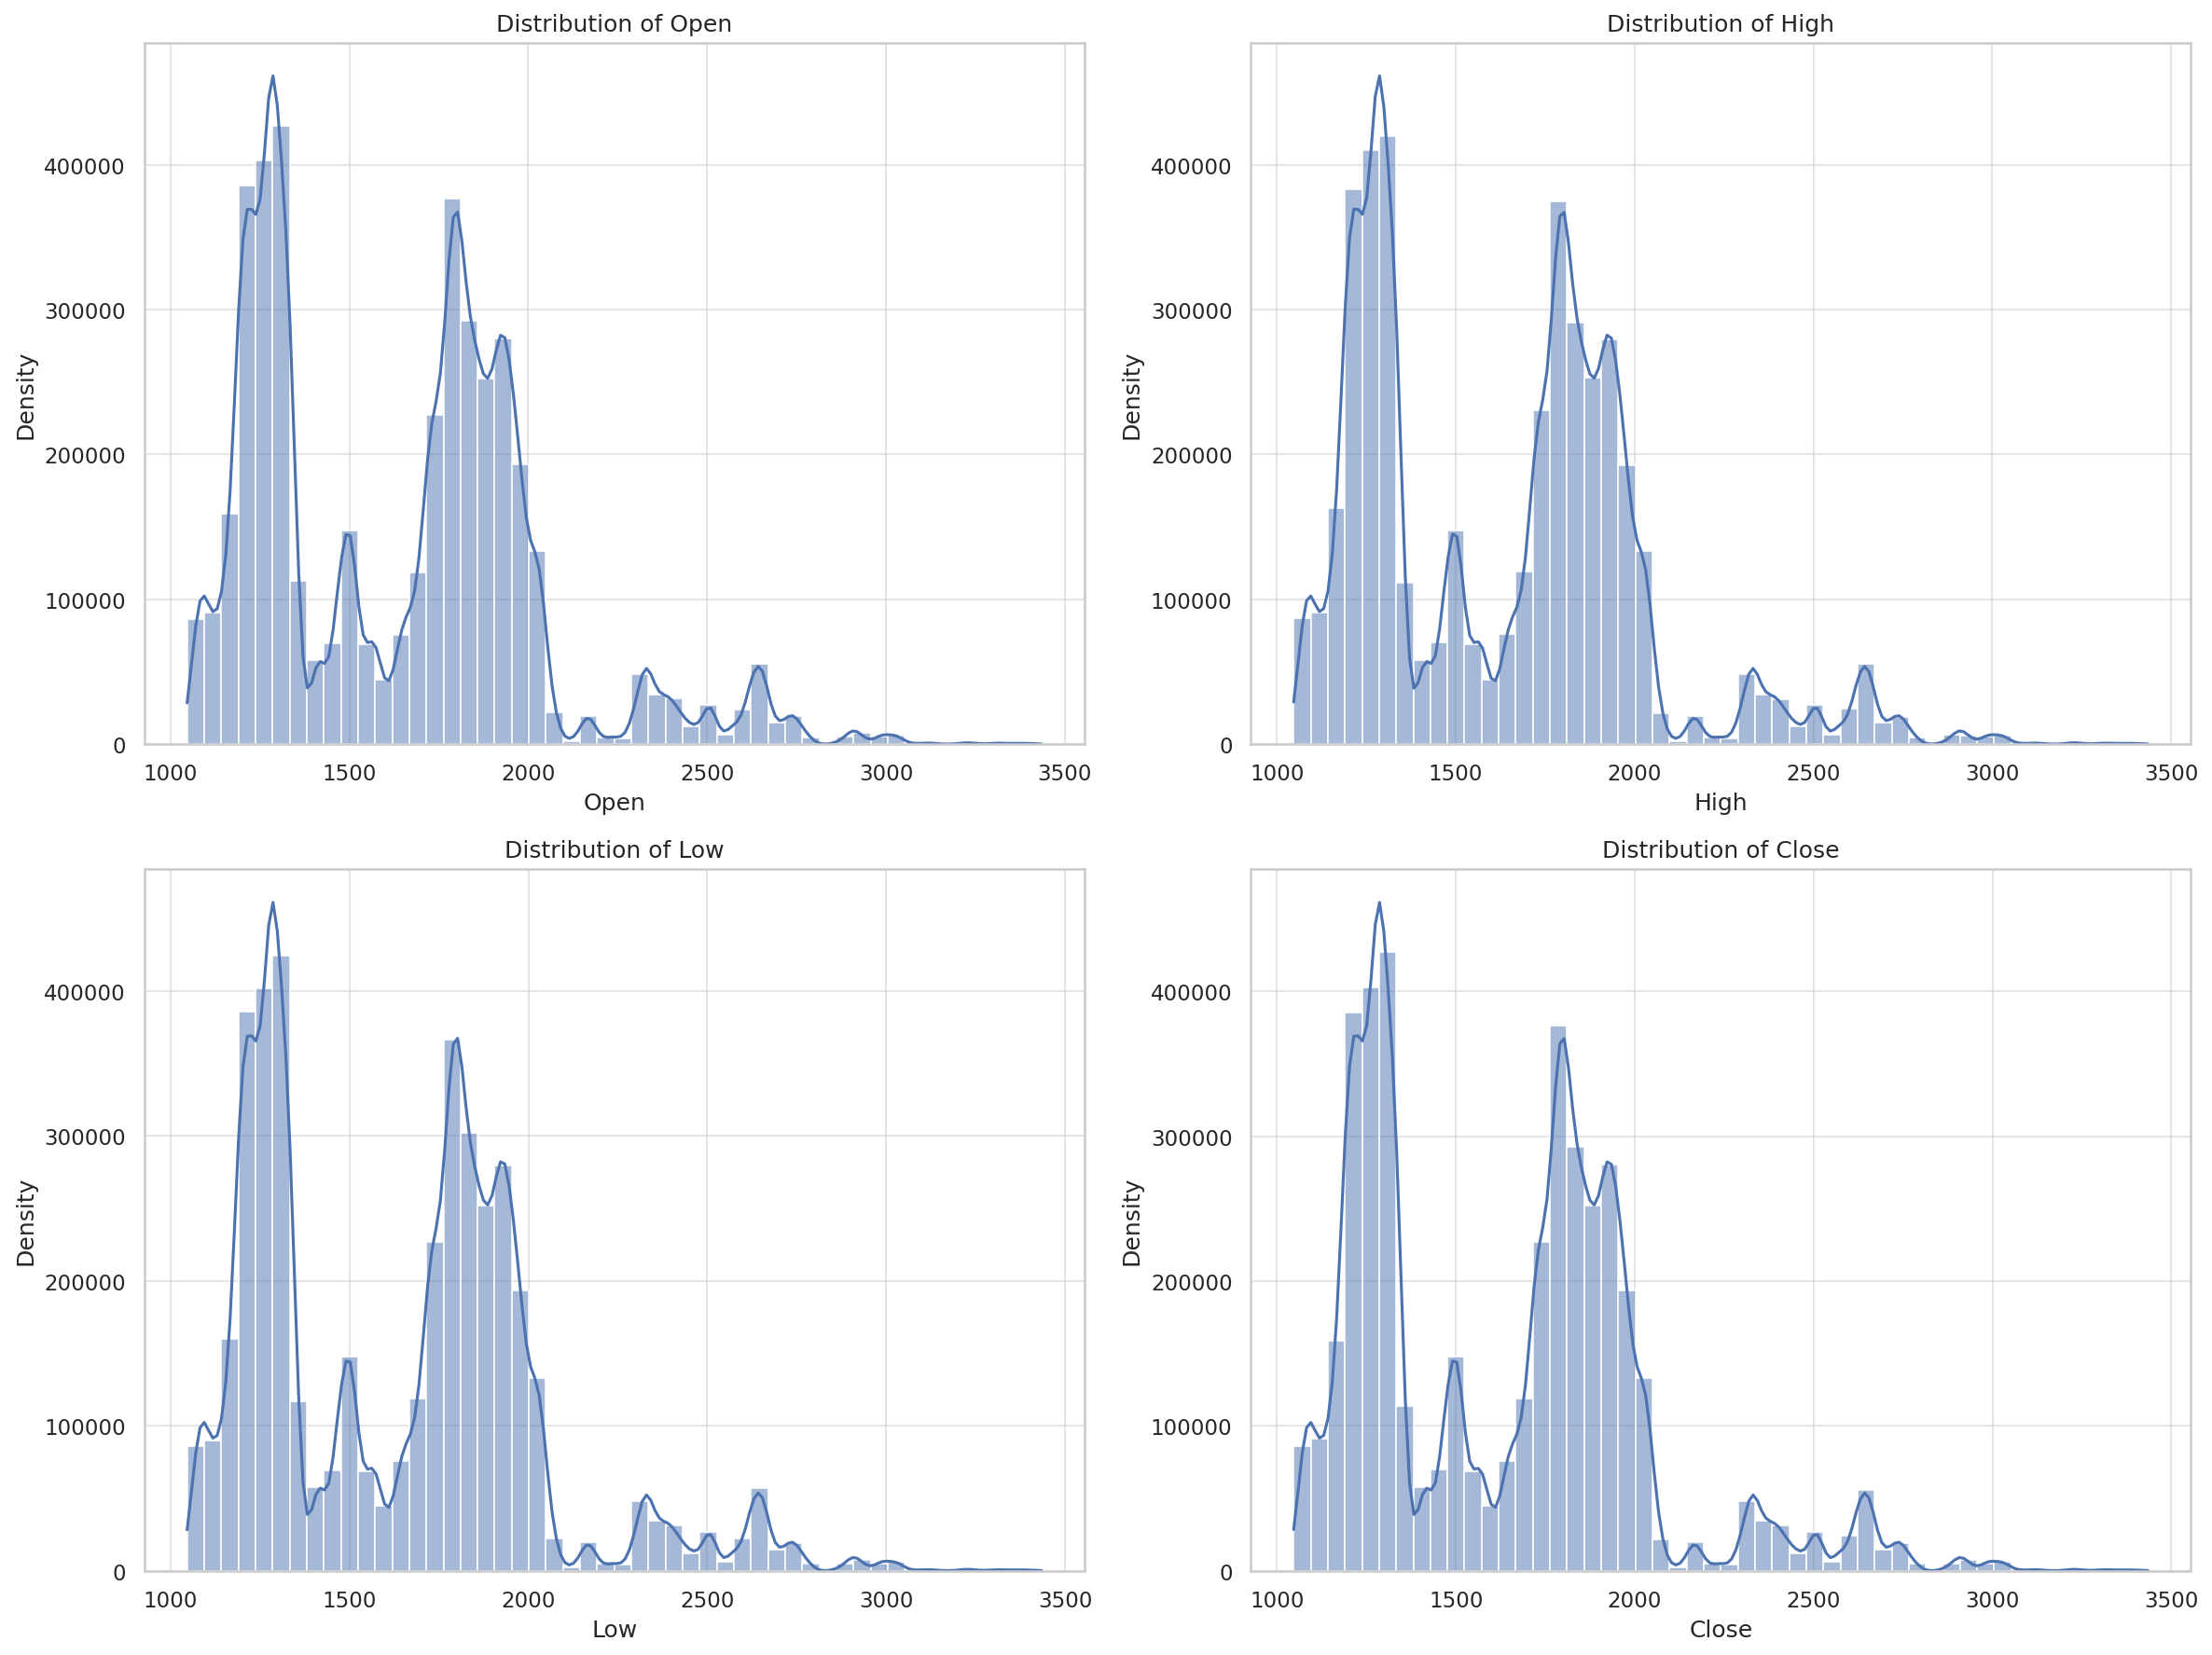

In [82]:
def plot_dataframe_distributions(df: pd.DataFrame) -> None:
    columns_to_plot = [col for col in df.columns if col not in ['Unnamed: 0','Volume']]
    num_columns = len(columns_to_plot)

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 6 * 2))
    axes_flat = axes.flatten()

    for index, col_name in enumerate(columns_to_plot):
        current_ax = axes_flat[index]

        sns.histplot(
            data=df,
            x=col_name,
            kde=True,
            ax=current_ax,
            bins=50
        )

        current_ax.ticklabel_format(style='plain', axis='both')
        current_ax.set_title(f'Distribution of {col_name}')
        current_ax.set_xlabel(col_name)
        current_ax.set_ylabel('Density')

    for remaining_index in range(num_columns, len(axes_flat)):
        fig.delaxes(axes_flat[remaining_index])
    plt.tight_layout()
    plt.show()

plot_dataframe_distributions(load_df)

In [83]:
def transform_ohlc_prices(data_frame: pd.DataFrame, price_columns: list) -> pd.DataFrame:
    transformed_df = data_frame.copy()
    for col in price_columns:
        transformed_df[f"{col}_Log"] = np.log(transformed_df[col])
        transformed_df[f"{col}_Absolute_Diff"] = transformed_df[col].diff()
        transformed_df[f"{col}_Log_Returns"] = transformed_df[f"{col}_Log"].diff()
    transformed_df = transformed_df.dropna()
    return transformed_df

target_cols = ["Open", "High", "Low", "Close"]

final_output = transform_ohlc_prices(data_frame=load_df, price_columns=target_cols)

pd.set_option("display.max_columns", None)

In [84]:
log_returns = final_output[['Open_Log_Returns','High_Log_Returns','Low_Log_Returns','Close_Log_Returns']]

In [86]:
log_returns

,Open_Log_Returns,High_Log_Returns,Low_Log_Returns,Close_Log_Returns
Gmt time,,,,
2015-01-01 00:02:00,0.000000,0.000000,0.000000,0.000000
2015-01-01 00:03:00,0.000000,0.000000,0.000000,0.000000
2015-01-01 00:04:00,0.000000,0.000000,0.000000,0.000000
2015-01-01 00:05:00,0.000000,0.000000,0.000000,0.000000
2015-01-01 00:06:00,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...
2025-06-30 22:55:00,-0.000463,-0.000276,0.000006,0.000168
2025-06-30 22:56:00,0.000206,0.000151,0.000172,0.000091
2025-06-30 22:57:00,0.000069,-0.000082,-0.000356,-0.000453


In [87]:
final_output[['Open_Log_Returns','High_Log_Returns','Low_Log_Returns','Close_Log_Returns']]

,Open_Log_Returns,High_Log_Returns,Low_Log_Returns,Close_Log_Returns
Gmt time,,,,
2015-01-01 00:02:00,0.000000,0.000000,0.000000,0.000000
2015-01-01 00:03:00,0.000000,0.000000,0.000000,0.000000
2015-01-01 00:04:00,0.000000,0.000000,0.000000,0.000000
2015-01-01 00:05:00,0.000000,0.000000,0.000000,0.000000
2015-01-01 00:06:00,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...
2025-06-30 22:55:00,-0.000463,-0.000276,0.000006,0.000168
2025-06-30 22:56:00,0.000206,0.000151,0.000172,0.000091
2025-06-30 22:57:00,0.000069,-0.000082,-0.000356,-0.000453
